# Introducción a la Inteligencia Artificial
## Trabajo Práctico 1 - Sistemas Expertos, Lógica Difusa y Ontologías
---

## Integrantes - Grupo 1 Equipo 5


| Nombre | Correo |
|---|---|
|Luisa María Rendón Grajales	|lurendong@unal.edu.co|
|Jerónimo Hoyos Botero	|jhoyosbo@unal.edu.co|
|Juanita Valentina Rosero Rosero|	juroseror@unal.edu.co|
|Rafael Junior Florez Rivera|	raflorezr@unal.edu.co|

## Situaciones por categoría

### Vivienda
- Problemas con el contrato de arrendamiento, cobros, mora, restitución, entrega del inmueble o desalojo.
- Falta de reparaciones, problemas de habitabilidad, servicios públicos o defectos de construcción.
- Problemas de propiedad, escritura, sucesión, subsidios, legalización, zonas de riesgo o reubicación.

### Conflictos territoriales
- Problemas de límites, linderos, propiedad, posesión, ocupación, herencia o formalización de un terreno.
- Dificultades relacionadas con el uso del suelo, licencias de construcción, espacio público, asentamientos o actividades económicas informales.
- Desplazamiento, riesgo de desastre, afectaciones ambientales o falta de participación en decisiones sobre el territorio.

### Violencia intrafamiliar
- Insultos, humillaciones, amenazas, control, aislamiento o vigilancia.
- Agresión física o violencia sexual.
- Control del dinero, apropiación de bienes, documentos o recursos.
- Violencia o negligencia contra niños, personas mayores, personas con discapacidad o personas dependientes.
- Incumplimiento de medidas de protección o negativa, demora o atención inadecuada de una institución.

## Configuración

In [29]:
# Librerias base
import numpy as np
import matplotlib.pyplot as plt

# Parche Experta
import collections.abc
if not hasattr(collections, 'Mapping'):
    collections.Mapping = collections.abc.Mapping

# Sistema experto
from experta import Fact, Rule, KnowledgeEngine, AS, MATCH

# Lógica difusa
import skfuzzy as fuzz
from skfuzzy import control as ctrl

print('✓ Entorno listo')

✓ Entorno listo


## Módulo de Sistema Experto

In [30]:
# Clase de hecho 1
class Consulta(Fact):
    """Caso consultado: categoría, tipo de situación y derecho aplicable."""
    pass

# Clase de hecho 2
class AutoridadCompetente(Fact):
    """Entidad a la que debe dirigirse el caso."""
    pass

# Clase de hecho 3
class PasoASeguir(Fact):
    """Paso o trámite recomendado."""
    pass

# Clase de hecho 4
class FuenteOficial(Fact):
    """Norma que respalda la recomendación."""
    pass

# Clase de hecho 5
class Recomendacion(Fact):
    """Orientación final con nivel de urgencia."""
    pass

| Categoría | Salience | Justificación |
|---|---|---|
| violencia_intrafamiliar | 100 | Riesgo directo a la integridad física o psicológica de las personas |
| vivienda | 50 | Afecta derechos patrimoniales y de habitabilidad |
| territorial | 20 | Generalmente trámites administrativos, urgencia menor |

In [31]:
class AsistenteJuridico(KnowledgeEngine):

    # Vivienda

    # Regla 1
    @Rule(Consulta(categoria="vivienda", tipo="arrendamiento_cobros_mora_restitucion_desalojo"),
          salience=50)
    def vivienda_arrendamiento_desalojo(self):
        print("Vivienda: problemas con el contrato de arrendamiento, cobros, mora, restitución, entrega del inmueble o desalojo.")

        self.declare(AutoridadCompetente(entidad="juzgado_civil"))
        self.declare(Recomendacion(tipo_ayuda="asesoria_restitucion"))

    # Regla 2
    @Rule(Consulta(categoria="vivienda", tipo="habitabilidad_servicios_publicos_construccion"),
          salience=50)
    def vivienda_habitabilidad(self):
        print("Vivienda: falta de reparaciones, problemas de habitabilidad, servicios públicos o defectos de construcción.")

        self.declare(AutoridadCompetente(entidad="personeria"))
        self.declare(Recomendacion(tipo_ayuda="reporte_habitabilidad"))

    # Regla 3
    @Rule(Consulta(categoria="vivienda", tipo="propiedad_escritura_sucesion_subsidios_reubicacion"),
          salience=50)
    def vivienda_propiedad_sucesion(self):
        print("Vivienda: problemas de propiedad, escritura, sucesión, subsidios, legalización, zonas de riesgo o reubicación.")

        self.declare(FuenteOficial(norma="Codigo_Civil_sucesiones"))
        self.declare(Recomendacion(tipo_ayuda="consultorio_juridico_titulacion"))

    # Conflictos Territoriales

    # Regla 4
    @Rule(Consulta(categoria="territorial", tipo="limites_linderos_posesion_herencia_formalizacion"),
          salience=20)
    def territorial_linderos(self):
        print("Conflictos territoriales: problemas de límites, linderos, propiedad, posesión, ocupación, herencia o formalización de un terreno.")

        self.declare(Recomendacion(tipo_ayuda="centro_conciliacion"))

    # Regla 5
    @Rule(Consulta(categoria="territorial", tipo="uso_suelo_licencias_espacio_publico_informalidad"),
          salience=20)
    def territorial_uso_suelo(self):
        print("Conflictos territoriales: dificultades relacionadas con el uso del suelo, licencias de construcción, espacio público, asentamientos o actividades económicas informales.")

        self.declare(AutoridadCompetente(entidad="curaduria_urbana"))
        self.declare(Recomendacion(tipo_ayuda="consulta_plan_ordenamiento"))

    # Regla 6
    @Rule(Consulta(categoria="territorial", tipo="desplazamiento_riesgo_desastre_afectacion_ambiental"),
          salience=20)
    def territorial_desplazamiento(self):
        print("Conflictos territoriales: desplazamiento, riesgo de desastre, afectaciones ambientales o falta de participación en decisiones sobre el territorio.")

        self.declare(AutoridadCompetente(entidad="unidad_victimas"))
        self.declare(Recomendacion(tipo_ayuda="ruta_atencion_desplazamiento"))

    # Violencia Intrafamiliar

    # Regla 7
    @Rule(Consulta(categoria="violencia_intrafamiliar", tipo="insultos_amenazas_control_aislamiento_vigilancia"),
          salience=100)
    def violencia_control_psicologico(self):
        print("Violencia intrafamiliar: insultos, humillaciones, amenazas, control, aislamiento o vigilancia.")

        self.declare(Recomendacion(tipo_ayuda="apoyo_psicosocial"))

    # Regla 8
    @Rule(Consulta(categoria="violencia_intrafamiliar", tipo="agresion_fisica_violencia_sexual"),
          salience=100)
    def violencia_agresion_fisica(self):
        print("Violencia intrafamiliar: agresión física o violencia sexual.")

        self.declare(AutoridadCompetente(entidad="comisaria_familia_fiscalia"))
        self.declare(FuenteOficial(norma="Ley_1257_de_2008"))
        self.declare(Recomendacion(tipo_ayuda="medida_proteccion_urgente"))

    # Regla 9
    @Rule(Consulta(categoria="violencia_intrafamiliar", tipo="control_dinero_apropiacion_bienes"),
          salience=100)
    def violencia_control_economico(self):
        print("Violencia intrafamiliar: control del dinero, apropiación de bienes, documentos o recursos.")

        self.declare(Recomendacion(tipo_ayuda="orientacion_juridica_patrimonial"))

    # Regla 10
    @Rule(Consulta(categoria="violencia_intrafamiliar", tipo="violencia_negligencia_ninos_mayores_discapacidad"),
          salience=100)
    def violencia_poblacion_dependiente(self):
        print("Violencia intrafamiliar: violencia o negligencia contra niños, personas mayores, personas con discapacidad o personas dependientes.")

        self.declare(AutoridadCompetente(entidad="icbf_comisaria_familia"))
        self.declare(Recomendacion(tipo_ayuda="proteccion_poblacion_dependiente"))

    # Regla 11
    @Rule(Consulta(categoria="violencia_intrafamiliar", tipo="incumplimiento_medida_atencion_inadecuada"),
          salience=100)
    def violencia_incumplimiento_medida(self):
        print("Violencia intrafamiliar: incumplimiento de medidas de protección o negativa, demora o atención inadecuada de una institución.")

        self.declare(AutoridadCompetente(entidad="comisaria_familia"))
        self.declare(Recomendacion(tipo_ayuda="reactivar_ruta_proteccion"))



## Módulo de Lógica Difusa

In [32]:
# Gravedad: qué tan severo es el hecho relatado (un insulto no es igual que una agresión física)
gravedad = ctrl.Antecedent(np.arange(0, 101, 1), 'gravedad')

# Vulnerabilidad: si la persona afectada es un niño, un adulto mayor, alguien con discapacidad, etc.
vulnerabilidad = ctrl.Antecedent(np.arange(0, 101, 1), 'vulnerabilidad')

# Prioridad de atención: qué tan urgente debe ser la respuesta institucional ante el caso
prioridad_atencion = ctrl.Consequent(np.arange(0, 101, 1), 'prioridad_atencion')

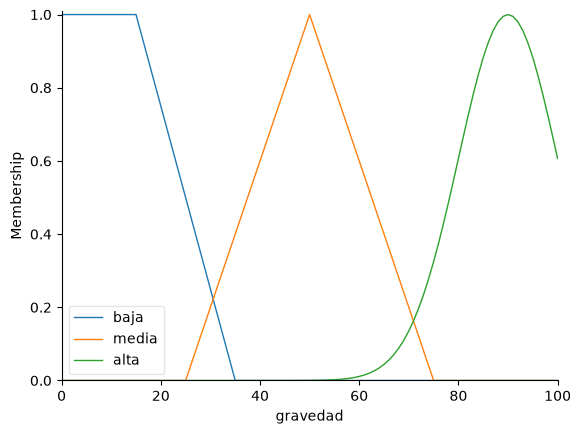

In [33]:
# GRAVEDAD - valores difusos y funciones de pertenencia
# baja: hecho leve (trapezoidal)
gravedad['baja'] = fuzz.trapmf(gravedad.universe, [0, 0, 15, 35])

# media: hecho de gravedad intermedia (triangular)
gravedad['media'] = fuzz.trimf(gravedad.universe, [25, 50, 75])

# alta: hecho grave, ej. agresión física (Gaussiana)
gravedad['alta'] = fuzz.gaussmf(gravedad.universe, 90, 10)


gravedad.view()

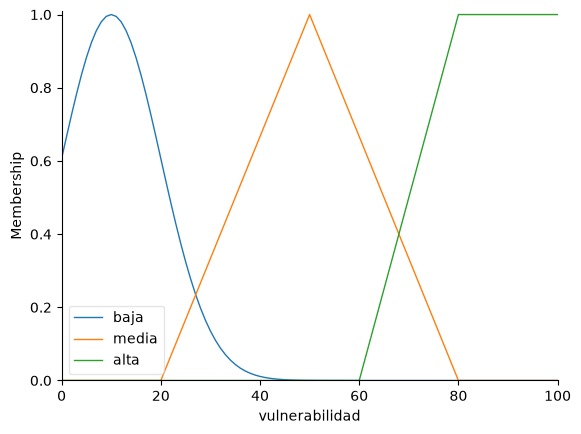

In [34]:
# Vulnerabilidad

# baja: sin factores de vulnerabilidad 
vulnerabilidad['baja'] = fuzz.gaussmf(vulnerabilidad.universe, 10, 10)

# media: algunos factores de vulnerabilidad 
vulnerabilidad['media'] = fuzz.trimf(vulnerabilidad.universe, [20, 50, 80])

# alta: niño, adulto mayor o persona con discapacidad
vulnerabilidad['alta'] = fuzz.trapmf(vulnerabilidad.universe, [60, 80, 100, 100])

vulnerabilidad.view()

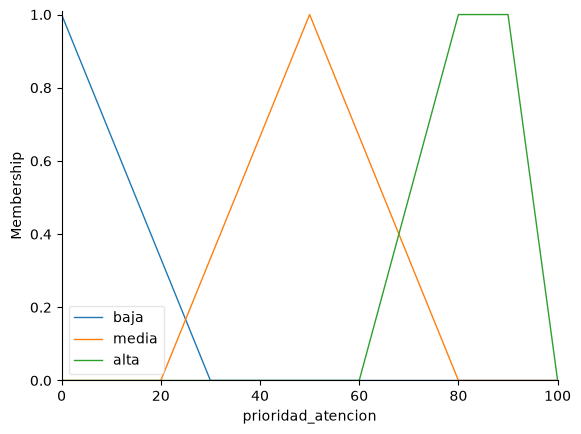

In [35]:
# Prioridad de atención

# baja: casos que pueden esperar 
prioridad_atencion['baja'] = fuzz.trimf(prioridad_atencion.universe, [0, 0, 30])

# media: prioridad intermedia
prioridad_atencion['media'] = fuzz.trimf(prioridad_atencion.universe, [20, 50, 80])

# alta: requiere atención pronta 
prioridad_atencion['alta'] = fuzz.trapmf(prioridad_atencion.universe, [60, 80, 90, 100])

prioridad_atencion.view()

In [36]:

# Concentración: eleva al cuadrado la pertenencia ("muy")
def concentracion(conjunto):
    return conjunto ** 2

# Dilatación: raíz cuadrada de la pertenencia ("ligeramente")
def dilatacion(conjunto):
    return conjunto ** 0.5

# "muy grave": concentración sobre gravedad alta
gravedad['muy_alta'] = concentracion(gravedad['alta'].mf)

# "ligeramente vulnerable": dilatación sobre vulnerabilidad alta
vulnerabilidad['ligeramente_alta'] = dilatacion(vulnerabilidad['alta'].mf)

In [37]:
# Reglas difusas

regla1 = ctrl.Rule(gravedad['alta'] & vulnerabilidad['alta'], prioridad_atencion['alta'])

regla2 = ctrl.Rule(gravedad['muy_alta'] & vulnerabilidad['media'], prioridad_atencion['alta'])

regla3 = ctrl.Rule(gravedad['alta'] | vulnerabilidad['alta'], prioridad_atencion['alta'])

regla4 = ctrl.Rule(gravedad['media'] & vulnerabilidad['media'], prioridad_atencion['media'])

regla5 = ctrl.Rule(gravedad['media'] | vulnerabilidad['ligeramente_alta'], prioridad_atencion['media'])

regla6 = ctrl.Rule(gravedad['baja'] & ~vulnerabilidad['alta'], prioridad_atencion['baja'])

regla7 = ctrl.Rule(~gravedad['alta'] & vulnerabilidad['baja'], prioridad_atencion['baja'])

regla8 = ctrl.Rule(gravedad['baja'] & vulnerabilidad['alta'], prioridad_atencion['media'])

regla9 = ctrl.Rule(gravedad['muy_alta'] & vulnerabilidad['baja'], prioridad_atencion['alta'])

sistema = ctrl.ControlSystem([regla1, regla2, regla3, regla4, regla5, regla6, regla7, regla8, regla9])
simulador = ctrl.ControlSystemSimulation(sistema)

In [ ]:
# Justificación y comparación de métodos de defuzzificación
def fuzzificar_y_agregar(g0, v0):
    #Evalúa las reglas para un par nítido y devuelve la región difusa agregada.
    g_baja = fuzz.interp_membership(gravedad.universe, gravedad['baja'].mf, g0)
    g_media = fuzz.interp_membership(gravedad.universe, gravedad['media'].mf, g0)
    g_alta = fuzz.interp_membership(gravedad.universe, gravedad['alta'].mf, g0)
    g_muy_alta = concentracion(g_alta)

    v_baja = fuzz.interp_membership(vulnerabilidad.universe, vulnerabilidad['baja'].mf, v0)
    v_media = fuzz.interp_membership(vulnerabilidad.universe, vulnerabilidad['media'].mf, v0)
    v_alta = fuzz.interp_membership(vulnerabilidad.universe, vulnerabilidad['alta'].mf, v0)
    v_ligeramente_alta = dilatacion(v_alta)

    # Fuerza de disparo por término de salida
    fuerza_alta = max(min(g_alta, v_alta), 
                      min(g_muy_alta, v_media), 
                      max(g_alta, v_alta), 
                      min(g_muy_alta, v_baja))
    fuerza_media = max(min(g_media, v_media), 
                       max(g_media, v_ligeramente_alta), 
                       min(g_baja, v_alta))
    fuerza_baja = max(min(g_baja, 1 - v_alta), 
                      min(1 - g_alta, v_baja))

    fuerzas = {'alta': fuerza_alta, 'media': fuerza_media, 'baja': fuerza_baja}

    agregada = np.zeros_like(prioridad_atencion.universe, dtype=float)
    for termino, fuerza in fuerzas.items():
        recorte = np.fmin(fuerza, prioridad_atencion[termino].mf)
        agregada = np.fmax(agregada, recorte)
    return agregada, fuerzas

# Comparación de métodos (gravedad=10, vulnerabilidad=10)
agregada, fuerzas = fuzzificar_y_agregar(10, 10)

print("Fuerza de disparo por término de salida:", {k: round(v, 3) for k, v in fuerzas.items()})
print("\nComparación de métodos de defuzzificación (gravedad=10, vulnerabilidad=10):")
for metodo in ['centroid', 'bisector', 'mom']:
    valor = fuzz.defuzz(prioridad_atencion.universe, agregada, metodo)
    print(f"  {metodo:10s} -> {valor:6.2f} / 100")

# Gráfica de la defuzzificación
plt.figure(figsize=(8, 4))
plt.fill_between(prioridad_atencion.universe, agregada, alpha=0.4, color='steelblue', label='región agregada')
for metodo, color in zip(['centroid', 'bisector', 'mom'], ['tab:red', 'tab:green', 'tab:orange']):
    valor = fuzz.defuzz(prioridad_atencion.universe, agregada, metodo)
    plt.axvline(valor, color=color, linestyle='--', label=f'{metodo} = {valor:.1f}')
plt.title('Defuzzificación de prioridad_atencion (gravedad=10, vulnerabilidad=10)')
plt.xlabel('prioridad_atencion')
plt.ylabel('grado de pertenencia')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Selección del método Centroide
prioridad_atencion.defuzzify_method = 'centroid'
print("\nMétodo de defuzzificación fijado explícitamente en:", prioridad_atencion.defuzzify_method)

In [ ]:
# Evaluación de casos de prueba en todo el rango
casos_prueba = [
    ("Caso leve",                                      10, 10),
    ("Caso intermedio",                                50, 50),
    ("Caso grave y vulnerable",                        85, 90),
    ("Poco grave, muy vulnerable (dispara OR)",        10, 95),
    ("Muy grave, poco vulnerable (dispara muy_alta)",  95, 5),
    ("Medio, vulnerab. ligeramente alta",              40, 65),
]

print(f"{'Caso':46s}{'gravedad':>10s}{'vulnerab.':>11s}{'prioridad':>11s}")
for nombre, g0, v0 in casos_prueba:
    simulador.input['gravedad'] = g0
    simulador.input['vulnerabilidad'] = v0
    simulador.compute()
    resultado = simulador.output['prioridad_atencion']
    print(f"{nombre:46s}{g0:10d}{v0:11d}{resultado:11.2f}")

Prioridad de atención estimada: 64.17/100


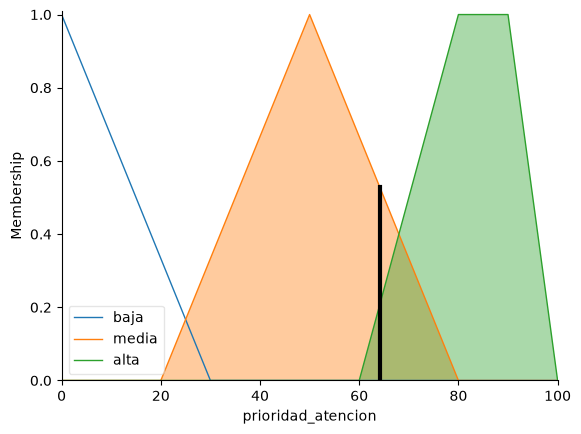

In [38]:
# Caso de ejemplo

simulador.input['gravedad'] = 85
simulador.input['vulnerabilidad'] = 90

simulador.compute()

# Mostrar resultado defuzzificado 
prioridad = simulador.output['prioridad_atencion']
print(f"Prioridad de atención estimada: {prioridad:.2f}/100")

prioridad_atencion.view(sim=simulador)

## Módulo de Ontología: